In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trait = ['INI30120', 'INI50030700', 'INI1003063', 'INI20030780']
data_d = '/home/lucytian/data/1_Single_Cell_PRS/2_cV2F/mvp_afr_0.9_0.01/20231221/406k_geno_v2_UKB_18PCs/fit_w_val'
tissue_trait_dict = {'INI30120' : 'BLOOD', 'INI20030780': 'LIVER', 'INI50030700': 'KIDNEY', 'INI1003063': 'LUNG', 'INI10030620': 'KIDNEY'}

In [3]:
df_evals = []
for tr in trait:
    #print(data_d + ti + '/' + tr + '/')
    if tr =='INI20030780':
        df_path = f'{data_d}/{tissue_trait_dict[tr]}/{tr}/exclude_APOE'
    else:
        df_path = f'{data_d}/{tissue_trait_dict[tr]}/{tr}'
        
    df = pd.read_csv(f'{df_path}/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
    df = df[(df['population'] == 'Afr') & (df['model'] == 'PGS') & (df['split'] == 'test')]
    df['cv2f_cutoff'] = 0.05
    df_evals.append(df)
    
    df = pd.read_csv(f'{df_path}/cv2f_0.01/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
    df = df[(df['population'] == 'Afr') & (df['model'] == 'PGS') & (df['split'] == 'test')]
    df['cv2f_cutoff'] = 0.01
    df_evals.append(df)
    
    df = pd.read_csv(f'{df_path}/cv2f_0.1/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
    df = df[(df['population'] == 'Afr') & (df['model'] == 'PGS') & (df['split'] == 'test')]
    df['cv2f_cutoff'] = 0.1
    df_evals.append(df)

In [4]:
df_full = pd.concat(df_evals)

In [5]:
df_full = df_full.sort_values(by='cv2f_cutoff')

In [6]:
df_full

,#response,predictors,metric,eval,l_eval,u_eval,P,n,split,population,model,cv2f_cutoff
21,INI30120,PGS_INI30120,R2,0.006556,-0.002471,0.015584,5.919548e-03,1213,test,Afr,PGS,0.01
21,INI50030700,PGS_INI50030700,R2,0.013639,0.000711,0.026567,8.081725e-05,1213,test,Afr,PGS,0.01
21,INI1003063,PGS_INI1003063,R2,0.004606,-0.002975,0.012188,2.586179e-02,1213,test,Afr,PGS,0.01
21,INI20030780,PGS_INI20030780,R2,0.071294,0.043465,0.099123,6.724148e-20,1213,test,Afr,PGS,0.01
21,INI1003063,PGS_INI1003063,R2,0.006667,-0.002435,0.015770,7.311969e-03,1213,test,Afr,PGS,0.05
21,INI50030700,PGS_INI50030700,R2,0.017899,0.003153,0.032644,6.166460e-06,1213,test,Afr,PGS,0.05
21,INI20030780,PGS_INI20030780,R2,0.076134,0.047526,0.104743,3.418093e-21,1213,test,Afr,PGS,0.05
21,INI30120,PGS_INI30120,R2,0.007271,-0.002229,0.016772,3.744762e-03,1213,test,Afr,PGS,0.05
21,INI50030700,PGS_INI50030700,R2,0.021592,0.005457,0.037726,6.703484e-07,1213,test,Afr,PGS,0.10
21,INI30120,PGS_INI30120,R2,0.007501,-0.002146,0.017147,3.235487e-03,1213,test,Afr,PGS,0.10


In [7]:
palette = sns.color_palette(palette='Paired')
color_trait_dict = {'INI30120' : palette[4], 'INI50030700': palette[0], 'INI1003063': palette[2], 'INI20030780': palette[6]}
name_dict = {'INI30120' : 'Lymphocyte Count', 'INI50030700': 'eGFR', 'INI1003063': 'FEV$_{1}$/FVC Ratio', 'INI20030780': 'LDL-C'}

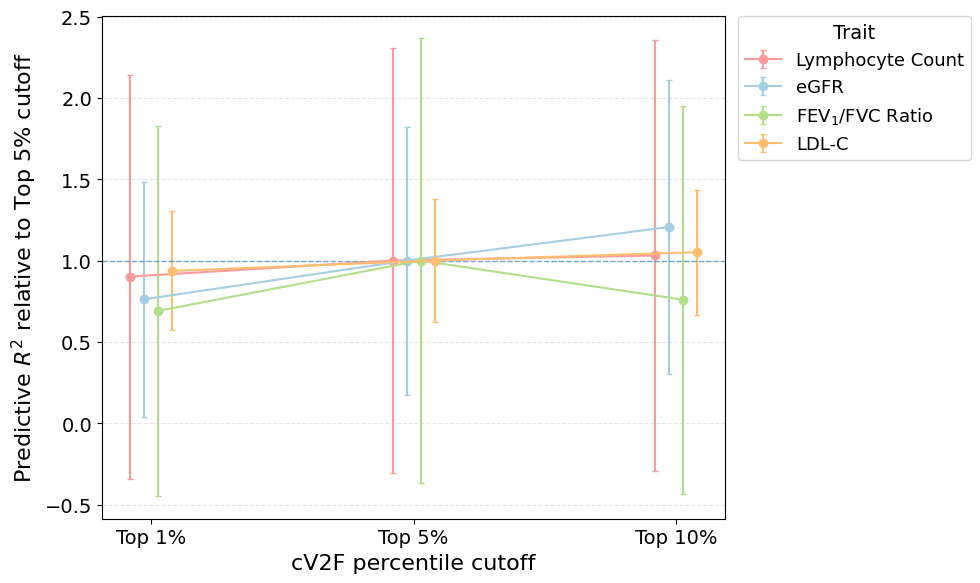

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Global font sizes
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12
})

fig, ax = plt.subplots(figsize=(10, 6))

cutoffs = [0.01, 0.05, 0.10]
x_pos = {0.01: 1, 0.05: 2, 0.10: 3}

jitter_width = 0.08
n_traits = len(trait)
offsets = np.linspace(-jitter_width, jitter_width, n_traits)

for i, tr in enumerate(trait):
    to_plot = df_full[df_full['#response'] == tr].sort_values('cv2f_cutoff').copy()

    # Reference value: Top 5% point for this trait
    ref_eval = to_plot.loc[to_plot['cv2f_cutoff'] == 0.05, 'eval'].iloc[0]

    # Normalize relative to Top 5%
    to_plot['eval_norm'] = to_plot['eval'] / ref_eval
    to_plot['l_eval_norm'] = to_plot['l_eval'] / ref_eval
    to_plot['u_eval_norm'] = to_plot['u_eval'] / ref_eval

    x = to_plot['cv2f_cutoff'].map(x_pos) + offsets[i]

    yerr = np.vstack([
        to_plot['eval_norm'] - to_plot['l_eval_norm'],
        to_plot['u_eval_norm'] - to_plot['eval_norm']
    ])

    ax.errorbar(
        x=x,
        y=to_plot['eval_norm'],
        yerr=yerr,
        fmt='o-',
        capsize=2,
        label=name_dict[tr],
        color=color_trait_dict[tr]
    )

ax.axhline(1, linestyle='--', linewidth=1, alpha=0.6)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Top 1%', 'Top 5%', 'Top 10%'])

ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.set_xlabel('cV2F percentile cutoff', fontsize=16)
ax.set_ylabel(r'Predictive $R^2$ relative to Top 5% cutoff', fontsize=16)

ax.tick_params(axis='both', labelsize=14)

ax.legend(
    title='Trait',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=13,
    title_fontsize=14
)

plt.tight_layout()
plt.savefig('sensitivity_analysis_normalized_to_top5.pdf', bbox_inches='tight')
plt.show()